In [1]:
### Function Five

In [2]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from scipy.optimize import minimize
from scipy.stats import norm

In [3]:
X = np.load("function_5/initial_inputs.npy")
X = np.append(X, [[0.220000, 0.628062, 0.879000, 0.879000],
                 [0.000050, 0.000050, 0.066897, 0.999959],
                 [0.189583, 0.886225, 0.999999, 0.999999],
                  [0.931828, 0.990000, 0.990000, 0.990000],
                  [0.000001, 0.000001, 0.999999, 0.999999],
                  	[0.189583, 0.990000, 0.628062, 0.990000],
                  [0.604315, 0.130222, 0.279877, 0.236729],
                  [0.990000, 0.990000, 0.990000, 0.990000],
                  [0.189583, 0.130222, 0.990000, 0.990000],
                  [0.999999, 0.000001, 0.999999, 0.999999],
                  [0.000001, 0.000001, 0.999999, 0.999999],
                  [0.960914, 0.990000, 0.990000, 0.990000]
                 
                 ],
              axis=0)

In [5]:
y= np.load("function_5/initial_outputs.npy")
y = np.append(y, [554.0079824696209,
              	190.72970845678554,
                 3213.2161678630946,
                 6986.351530669805,
                  1616.6257474282386,
                  1803.4228711413452,
                  75.74587132062693,
                  7915.738968949545,
                  	1460.073396444937,
                  4440.480873839292,
                  1616.6257474282386,
                  7423.0491157208,
                  8662.405001248297
                 ],
axis=0)

In [6]:
max(y)

7915.738968949545

In [6]:
X


array([[1.91447084e-01, 3.81933714e-02, 6.07417811e-01, 4.14584137e-01],
       [7.58652949e-01, 5.36517738e-01, 6.56000382e-01, 3.60341553e-01],
       [4.38349873e-01, 8.04339705e-01, 2.10245266e-01, 1.51294816e-01],
       [7.06050834e-01, 5.34191961e-01, 2.64243345e-01, 4.82087549e-01],
       [8.36477993e-01, 1.93609647e-01, 6.63892697e-01, 7.85648883e-01],
       [6.83432250e-01, 1.18662642e-01, 8.29045910e-01, 5.67576606e-01],
       [5.53621480e-01, 6.67349979e-01, 3.23805819e-01, 8.14869754e-01],
       [3.52356269e-01, 3.22241532e-01, 1.16979368e-01, 4.73112522e-01],
       [1.53785706e-01, 7.29381690e-01, 4.22598437e-01, 4.43074166e-01],
       [4.63442267e-01, 6.30024510e-01, 1.07906456e-01, 9.57643899e-01],
       [6.77491148e-01, 3.58509507e-01, 4.79592224e-01, 7.28804811e-02],
       [5.83973412e-01, 1.47242646e-01, 3.48097462e-01, 4.28614651e-01],
       [3.06888719e-01, 3.16878127e-01, 6.22634481e-01, 9.53990581e-02],
       [5.11141775e-01, 8.17956997e-01, 7.28710418e

In [7]:
y

array([6.44434399e+01, 1.83013796e+01, 1.12939795e-01, 4.21089813e+00,
       2.58370525e+02, 7.84343889e+01, 5.75715369e+01, 1.09571876e+02,
       8.84799176e+00, 2.33223610e+02, 2.44230883e+01, 6.44201468e+01,
       6.34767158e+01, 7.97291299e+01, 3.55806818e+02, 1.08885962e+03,
       2.88667516e+01, 4.51815703e+01, 4.31612757e+02, 9.97233189e+00,
       5.54007982e+02, 1.90729708e+02, 3.21321617e+03, 6.98635153e+03,
       1.61662575e+03, 1.80342287e+03, 7.57458713e+01, 7.91573897e+03,
       1.46007340e+03, 4.44048087e+03])

In [8]:
# Log-transform to handle the large range of yields
y_log = np.log1p(y)
current_best_log = np.max(y_log)

In [9]:
y_log

array([4.18118626, 2.96017658, 0.10700498, 1.65075223, 5.55825764,
       4.37493138, 4.07024886, 4.70566577, 2.28726755, 5.45627626,
       3.23565775, 4.18083027, 4.16630416, 4.39109948, 5.87719451,
       6.99380418, 3.39674588, 3.83258081, 6.069843  , 2.39537682,
       6.3189825 , 5.25608661, 8.0753388 , 8.85185687, 7.38871477,
       7.49799608, 4.34049959, 8.97673465, 7.28692665, 8.39874313])

In [10]:
# 1. Define the Kernel
# C(1.0) allows the model to scale the overall variance of the log-outputs.
# Matern with 4 length_scales allows each chemical parameter to affect the yield differently.
kernel = C(1.0, (1e-3, 1e3)) * Matern(
    length_scale=[0.1, 0.1, 0.1, 0.1], 
    length_scale_bounds=(0.01, 10.0), 
    nu=2.5
)

# 2. Define the Model
# alpha=1e-2 (or 1e-3) adds a small amount of 'noise' to the diagonal of the kernel matrix.
# This improves numerical stability during the log-transform fitting.
model = GaussianProcessRegressor(
    kernel=kernel, 
    alpha=1, 
    n_restarts_optimizer=40,  # Increased restarts for 4D space
    normalize_y=True          # Standardizing log-yields helps the kernel optimizer converge
)

# 3. Fit the model to your log-transformed data
# y_log = np.log1p(y)
model.fit(X, y_log)

/Users/theshiekh/Library/Caches/pypoetry/virtualenvs/emeritus-poXcNCb8-py3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/theshiekh/Library/Caches/pypoetry/virtualenvs/emeritus-poXcNCb8-py3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".","1**2 * Matern... 0.1], nu=2.5)"
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",40
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",True
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`Glo

In [11]:
# 1. Get the optimized kernel object
optimized_kernel = model.kernel_

# 2. Extract the length scales from the Matern component
# In a Product kernel (C * Matern), 'k2' is typically the second component
length_scales = optimized_kernel.get_params()['k2__length_scale']

# 3. Print them alongside the bounds you set
print("--- Hyperparameter Check ---")
for i, ls in enumerate(length_scales):
    print(f"Parameter x{i+1} Length Scale: {ls:.4f}")

# Check if we are hitting the limits (assuming bounds were 0.01 to 10.0)
if np.any(np.isclose(length_scales, 0.01)) or np.any(np.isclose(length_scales, 10.0)):
    print("\nWARNING: One or more length scales are hitting the bounds. Consider widening 'length_scale_bounds'.")

--- Hyperparameter Check ---
Parameter x1 Length Scale: 10.0000
Parameter x2 Length Scale: 10.0000
Parameter x3 Length Scale: 1.1374
Parameter x4 Length Scale: 0.5453



In [12]:
# 3. Expected Improvement (EI) Acquisition Function
def expected_improvement(x_test, xi=101):
    mu, sigma = model.predict(x_test.reshape(1, -1), return_std=True)
    
    # Calculate improvement over the current best
    imp = mu - current_best_log - xi
    Z = imp / sigma if sigma > 0 else 0
    
    # EI Formula: The 'score' of the point
    ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    
    # Return NEGATIVE because 'minimize' will find the highest score
    return -ei


# # ChatGPT
# def expected_improvement(x_test, xi=0.01):
#     mu, sigma = model.predict(x_test.reshape(1, -1), return_std=True)
    
#     sigma = np.maximum(sigma, 1e-9)  # <-- critical fix
    
#     imp = mu - current_best_log - xi
#     Z = imp / sigma
    
#     ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    
#     return -ei

In [13]:
def upper_confidence_bound(x_test, kappa=10):
    """
    UCB Acquisition Function
    kappa=2.576 corresponds to a 99% confidence interval.
    Common values: 1.0 (exploitative) to 5.0+ (exploratory).
    """
    mu, sigma = model.predict(x_test.reshape(1, -1), return_std=True)
    
    # UCB Formula
    ucb = mu + kappa * sigma
    
    # Return NEGATIVE because 'minimize' will find the highest score
    return -ucb

In [14]:
# # Instead of one start, try many random starts to find global EI maximum
# best_ei = 1e10
# best_x = None
# x_best = X[np.argmax(y)]

# for _ in range(100):

#     res = minimize(expected_improvement, x_random, bounds=[(0.01, 0.99)] * 4, method='L-BFGS-B')
#     if res.fun < best_ei:
#         best_ei = res.fun
#         best_x = res.x

# print(f"Current Max Yield: {np.max(y_log)}")
# print(f"--- SUGGESTION FOR RUN #21 ---")
# print(f"Chemical Parameters: {best_x}")

In [15]:
# Instead of one start, try many random starts to find global EI maximum

x_best = X[np.argmax(y)]
res = minimize(expected_improvement, x_best, bounds=[(0.01, 0.99)] * 4, method='L-BFGS-B')
next_point = res.x

print(f"Current Max Yield: {np.max(y_log)}")
print(f"--- SUGGESTION FOR RUN #21 ---")
print(f"Chemical Parameters: {x_best}")

Current Max Yield: 8.976734653672915
--- SUGGESTION FOR RUN #21 ---
Chemical Parameters: [0.99 0.99 0.99 0.99]


In [16]:
# # UCB
def get_next_candidate(model, bounds, kappa=2.576, n_restarts=10):
    best_x = None
    min_ucb = float('inf')
    
    # We run the optimizer from multiple random starting points 
    # to ensure we find the true maximum of the UCB function.
    for starting_point in np.random.uniform(bounds[:, 0], bounds[:, 1], size=(n_restarts, 4)):
        res = minimize(
            fun=upper_confidence_bound,
            x0=starting_point,
            args=(kappa,),
            bounds=bounds,
            method='L-BFGS-B'
        )
        
        if res.fun < min_ucb:
            min_ucb = res.fun
            best_x = res.x
            
    return best_x

# Define your 4D bounds (assuming 0 to 1 based on your data)
bounds = np.array([[0, 1], [0, 1], [0, 1], [0, 1]])

# Get the next point to sample
next_x = get_next_candidate(model, bounds, kappa=5.0) # High kappa to find peaks
next_point = next_x
print(f"Next point to sample: {next_x}")

Next point to sample: [1. 0. 1. 1.]


In [17]:
import numpy as np


# 1. Get the indices that would sort the array from lowest to highest
sorted_indices = np.argsort(y_log)

# 2. Use those indices to get the sorted values
sorted_values = y_log[sorted_indices]

# 3. Display the Rank, Original Index, and Value
print(f"{'Rank':<6} | {'Orig Index':<10} | {'Value':<10}")
print("-" * 32)
for rank, idx in enumerate(sorted_indices):
    print(f"{rank:<6} | {idx:<10} | {sorted_values[rank]:.2f}")

Rank   | Orig Index | Value     
--------------------------------
0      | 2          | 0.11
1      | 3          | 1.65
2      | 8          | 2.29
3      | 19         | 2.40
4      | 1          | 2.96
5      | 10         | 3.24
6      | 16         | 3.40
7      | 17         | 3.83
8      | 6          | 4.07
9      | 12         | 4.17
10     | 11         | 4.18
11     | 0          | 4.18
12     | 26         | 4.34
13     | 5          | 4.37
14     | 13         | 4.39
15     | 7          | 4.71
16     | 21         | 5.26
17     | 9          | 5.46
18     | 4          | 5.56
19     | 14         | 5.88
20     | 18         | 6.07
21     | 20         | 6.32
22     | 15         | 6.99
23     | 28         | 7.29
24     | 24         | 7.39
25     | 25         | 7.50
26     | 22         | 8.08
27     | 29         | 8.40
28     | 23         | 8.85
29     | 27         | 8.98


In [18]:
import torch
# Custom Labels: Start with all zeros (Negative)
y_labels = np.zeros(len(X))


positive_indices = [24,25,23,22,15,20,18,14,4,9,21,7]
y_labels[positive_indices] = 1

# 1. Setup Data
X_tensor = torch.tensor(X, dtype=torch.float32, requires_grad=True)

y_tensor = torch.tensor(y_labels, dtype=torch.float32).reshape(-1, 1)

In [19]:
# Deep layer

In [20]:

import torch
import torch.nn as nn
import torch.optim as optim

# 1. Define a deeper architecture
model = nn.Sequential(
    nn.Linear(4, 16),      # Hidden layer: 2 inputs -> 10 neurons
    nn.ReLU(),             # Non-linear activation
    nn.Linear(16, 1),      # Output layer: 10 neurons -> 1 output
    nn.Sigmoid()
)

# 2. Setup the rest as before
optimizer = optim.Adam(model.parameters(), lr=0.01) # Adam is better for deeper nets
criterion = nn.BCELoss()

# 3. Training Loop
for _ in range(2000):
    optimizer.zero_grad()
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()
       
# Importance scores
deep_importance = X_tensor.grad.abs().sum(dim=1).detach().numpy()

print("Point | Deep Importance Score")
for i, score in enumerate(deep_importance):
    print(f"{i:2d}    | {score:.4f}")


Point | Deep Importance Score
 0    | 26.9998
 1    | 2.9149
 2    | 3.3494
 3    | 5.8759
 4    | 153.1858
 5    | 13.6813
 6    | 194.4305
 7    | 251.0581
 8    | 120.5892
 9    | 24.9879
10    | 1.2089
11    | 44.0281
12    | 2.7134
13    | 2.4184
14    | 75.8107
15    | 9.9816
16    | 73.4579
17    | 3.6348
18    | 8.5781
19    | 4.2941
20    | 41.0848
21    | 2.8384
22    | 4.5629
23    | 1117.9250
24    | 334.1703
25    | 4.9530
26    | 3.5172
27    | 1029.3472
28    | 466.8989
29    | 35.8215


In [21]:
# Clear gradients and do a fresh pass for saliency
X_tensor.grad.zero_()
output = model(X_tensor)
output.backward(torch.ones_like(output))

# Importance scores
deep_importance = X_tensor.grad.abs().sum(dim=1).detach().numpy()

print("Point | Deep Importance Score")
for i, score in enumerate(deep_importance):
    print(f"{i:2d}    | {score:.4f}")

Point | Deep Importance Score
 0    | 0.0089
 1    | 0.0000
 2    | 0.0000
 3    | 0.0000
 4    | 0.2141
 5    | 0.0005
 6    | 0.5613
 7    | 0.6043
 8    | 0.5754
 9    | 0.0697
10    | 0.0000
11    | 0.0369
12    | 0.0000
13    | 0.0000
14    | 0.0010
15    | 0.0000
16    | 0.0000
17    | 0.0000
18    | 0.0000
19    | 0.0000
20    | 0.0018
21    | 0.0000
22    | 0.0000
23    | 11.4598
24    | 0.8419
25    | 0.0000
26    | 0.0000
27    | 10.9243
28    | 1.0718
29    | 0.0923


In [22]:
import torch

# 1. Prepare your sample input (must be a 2D tensor)
sample_input = torch.tensor([next_point], dtype=torch.float32)

# 2. Put the model in evaluation mode
model.eval()

# 3. Use 'no_grad' to save memory and compute power
with torch.no_grad():
    prediction_prob = model(sample_input)

# 4. View results
print(f"Next point    {next_point}")
print(f"Probability of being Positive (Class 1): {prediction_prob.item():.4f}")

# Convert probability to a hard label
predicted_label = 1 if prediction_prob.item() >= 0.5 else 0
print(f"Predicted Class: {predicted_label}")


Next point    [1. 0. 1. 1.]
Probability of being Positive (Class 1): 0.0008
Predicted Class: 0


/var/folders/b1/jr7k43v1395g6gvnq7gz_qq80000gn/T/ipykernel_3197/3007046121.py:4: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:278.)
  sample_input = torch.tensor([next_point], dtype=torch.float32)


In [23]:
len(y[10:])

20

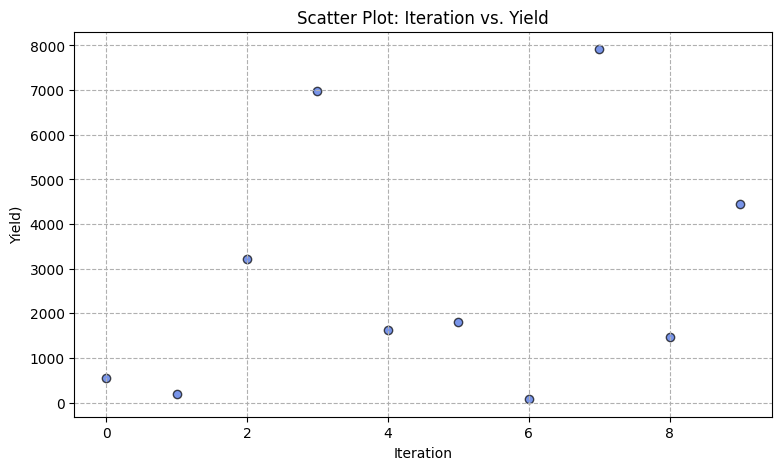

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.scatter(
    list(range(0,10)), y[-10:], color="royalblue", alpha=0.7, edgecolors="k"
)

# 3. Customization
plt.title("Scatter Plot: Iteration vs. Yield")
plt.xlabel("Iteration")
plt.ylabel("Yield)")
plt.grid(True, linestyle="--", alpha=1)

plt.show()